# 1. Construction of the Yield Curve

## Yield Curve

### Objective

The objective of this report was to build a yield curve that uses term-dependent risk-free rates and discount factors. The yield curve serves as a key piece in the valuatiion as it underpins all pricing and risk analysis. 

# 2. Environments and Import

The required operations including sys, numpy, pandas, and matplotlib.pyplot were installed and imported below. 

In [11]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve

# 3. Methodology Overview

The following four step methodology was applied:

1. Observed market zero rates at discrete maturities (0.25, 2, 3, 5 and 10 years). The market zero rates are Australian Government Bond Yields with 2-, 3-, 5-and 10-year maturities, with a monthly frequency, sourced from the Reserve Bank of Australia.
2. Interpolate zero rates for maturities using the function 'numpy.interp' which performs piecewise linear interpolation between points.
3. Compute discount factors consistently from those interpolated zero rates, using continuous compounding.
4. All code is inside the YieldCurve class in order for all rates and discount factors to be computed.

# 4. Input Yield Curve

The zero rates used to construct the curve are Australian Government Bond Yields with 2-, 3-, 5-and 10-year maturities, published monthly and sourced from the Reserve Bank of Australia. It is noted that the short 0.25-year maturity is proxied from the RBA cash rate target.

The zero rates are observed market prices and are not calibrated to a model. Therefore, the Yield Curve is treated as an input, with any valuation model built inheriting the same market-consistent discount rates. The zero rates loaded for their respective maturities are below:

In [12]:
from src.yieldcurve import YieldCurve, load_yield_data

df = load_yield_data()
curve = YieldCurve.from_dataframe(df, compounding="continuous")

In [13]:
test_maturites = [0.25, 2.0, 3.0]

for T in test_maturites:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T={T:.2f} years | zero rate={z:.2%} | discount factor={d:.4f}")

T=0.25 years | zero rate=4.30% | discount factor=0.9893
T=2.00 years | zero rate=4.69% | discount factor=0.9105
T=3.00 years | zero rate=4.69% | discount factor=0.8687


# 5. Construct the Yield Curve Object

The YieldCurve class is instantiated with the above market maturities and zero rates using continuous compounding. Continuous compounding is the standard measure in the Black-Scholes derivative pricing model and takes the formula of:

$$P(0,T) = e^{-z(T) \cdot T}$$

All downstream models call 'get_zero_rate' or 'get_discount_factor', meaning any changes to market data (eg: updated RBA cash rates) updates all downstream models without further modification.

# 6. Sanity Checks

To verify if the Yield Curve object behaves correctly, sanity checks were performed to test two fundamental properties of a Yield Curve:

1. Zero rates should increase with maturity as longer horizons reflect uncertainty and liquidity risk, hence investors demand a higher return.
2. Discount factors should decrease with maturity as money into the future is worth less today.

In [14]:
test_maturites = [0.25, 2.0, 3.0]

for T in test_maturites:
    z = curve.get_zero_rate(T)
    d = curve.get_discount_factor(T)
    print(f"T={T:.2f} years | zero rate={z:.2%} | discount factor={d:.4f}")

T=0.25 years | zero rate=4.30% | discount factor=0.9893
T=2.00 years | zero rate=4.69% | discount factor=0.9105
T=3.00 years | zero rate=4.69% | discount factor=0.8687


# 7. Yield Curve Plot

The plot below visualises the full-term structure from 3 months to 10 years. As observed, the curve is upwards sloping in nature as the zero rates rise steadily across all maturities.

**Key Observations**

- Between 3 months – 2 years, the curve rises steeply, as rates increase by 23bp from 4.10% (cash rate proxy) to 4.64% (2-year bond yield)
- The curve inverts slightly between 2-3 years, dipping from 4.64% to 4.60%, before recovering at the 5-year maturity of 4.63%
- The curve steepens again from 5-10 years, rising from 4.63% to 4.93%. This reflects the compensation investors demand as longer-dated bonds carry a higher premium.

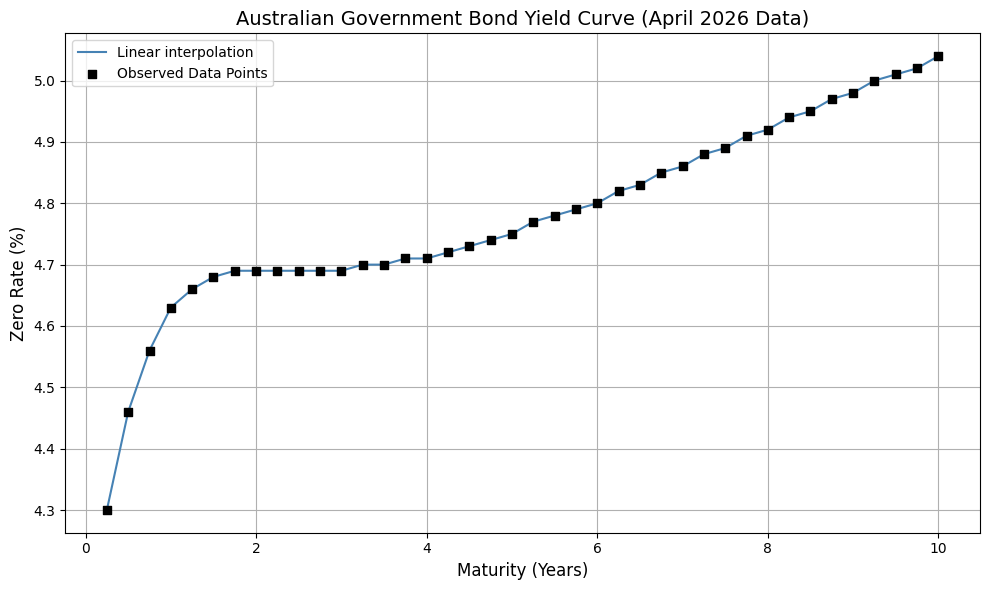

In [15]:
curve.plot()

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
sys.path.append("../src")

import yieldcurve
importlib.reload(yieldcurve)

from derivatives import EuropeanCall, EuropeanPut, EuropeanCallGreeks, AmericanPut, AsianCall
from portfolio import EquityPosition, Portfolio
from yieldcurve import YieldCurve, load_yield_data


# Data Overview

In [35]:
# Load equity data: prefer local cache, fallback to Yahoo Finance
from pathlib import Path
import os

tickers = {
    "BHP": "BHP.AX",
    "CBA": "CBA.AX",
    "CSL": "CSL.AX",
    "WOW": "WOW.AX"
}

all_data = {}

for name, ticker_code in tickers.items():
    data_path = Path(f'../data/Market_Data_{name}_prices.csv')

    if data_path.exists():
        df = pd.read_csv(data_path, parse_dates=['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        print(f'{name}: Loaded {len(df)} rows from cache')

    else:
        try:
            import yfinance as yf
        except Exception as e:
            raise ImportError(
                f"yfinance is not installed and local data is missing for {name}."
            ) from e

        ticker = yf.Ticker(ticker_code)
        df = ticker.history(period='2y')[['Close', 'Volume']]
        df.index = pd.to_datetime(df.index).tz_localize(None)
        df = df.dropna(subset=['Close'])
        df = df[~df.index.duplicated(keep='first')]
        df = df.sort_index()
        df = df.reset_index().rename(columns={'index': 'Date'})
        os.makedirs(data_path.parent, exist_ok=True)
        df.to_csv(data_path, index=False)
        print(f'{name}: Downloaded and cached {len(df)} rows to {data_path}')

    df.index = pd.to_datetime(df['Date'])
    all_data[name] = df

# Confirm results
for name, df in all_data.items():
    print(f"\n{name}: {df.index.min().date()} to {df.index.max().date()} "
          f"| {len(df)} trading days "
          f"| missing: {df.isnull().sum().to_dict()}")

# Keep BHP as df for any downstream cells that still reference it directly
df = all_data["BHP"]
df.index = pd.to_datetime(df['Date'])
# Confirm the result
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Total trading days: {len(df)}")
print(f"Missing values: {df.isnull().sum().to_dict()}")
print(df.tail())

BHP: Loaded 508 rows from cache
CBA: Downloaded and cached 508 rows to ../data/Market_Data_CBA_prices.csv
CSL: Downloaded and cached 508 rows to ../data/Market_Data_CSL_prices.csv
WOW: Downloaded and cached 508 rows to ../data/Market_Data_WOW_prices.csv

BHP: 2024-05-20 to 2026-05-20 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

CBA: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

CSL: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}

WOW: 2024-05-22 to 2026-05-22 | 508 trading days | missing: {'Date': 0, 'Close': 0, 'Volume': 0}
Date range: 2024-05-20 to 2026-05-20
Total trading days: 508
Missing values: {'Date': 0, 'Close': 0, 'Volume': 0}
                 Date      Close    Volume
Date                                      
2026-05-14 2026-05-14  62.060001   8798942
2026-05-15 2026-05-15  60.459999  10114056
2026-05-18 2026-05-18  58.770000   7699931
2026-05-19 2026-05-19  58

In [36]:
# ── Compute parameters for all equities ───────────────
equity_params = {}

for name, df in all_data.items():
    df["Return"] = df["Close"].pct_change()
    returns = df["Return"].dropna()
    S0_i    = df["Close"].iloc[-1]
    sigma_i = returns.std() * np.sqrt(252)
    K_i     = round(S0_i)
    equity_params[name] = {
        "S0": S0_i,
        "sigma": sigma_i,
        "K": K_i,
        "T": 1.0,
        "returns": returns
    }
    print(f"{name}: S0=${S0_i:.2f} | K=${K_i:.2f} | sigma={sigma_i:.2%}")

# ── Keep BHP variables for any downstream cells ────────
S0    = equity_params["BHP"]["S0"]
sigma = equity_params["BHP"]["sigma"]
K     = equity_params["BHP"]["K"]
T     = equity_params["BHP"]["T"]
bhp_returns = equity_params["BHP"]["returns"]


BHP: S0=$57.33 | K=$57.00 | sigma=24.92%
CBA: S0=$165.67 | K=$166.00 | sigma=23.17%
CSL: S0=$99.76 | K=$100.00 | sigma=29.54%
WOW: S0=$34.68 | K=$35.00 | sigma=22.30%


# Manual validation test
This is a quick manual validation section. It uses a fixed, manually specified yield curve and a simple European option pricing example to sanity-check the pricing functions independently of the main BHP dataset.

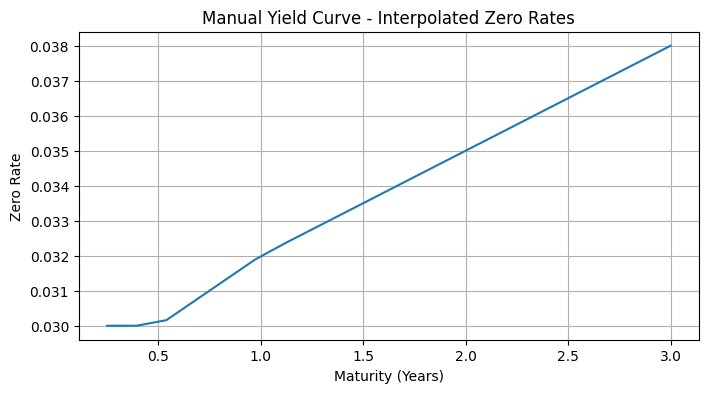

In [19]:
# Manual validation yield curve
manual_maturities = [0.5, 1.0, 2.0, 3.0]
manual_zero_rates = [0.03, 0.032, 0.035, 0.038]
yc_manual = YieldCurve(manual_maturities, manual_zero_rates)

manual_test_maturities = np.linspace(0.25, 3.0, 20)
manual_rates = [yc_manual.get_zero_rate(T) for T in manual_test_maturities]
manual_dfs = [yc_manual.get_discount_factor(T) for T in manual_test_maturities]

plt.figure(figsize=(8,4))
plt.plot(manual_test_maturities, manual_rates)
plt.title("Manual Yield Curve - Interpolated Zero Rates")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

In [20]:
# Manual validation option pricing test
manual_S0 = 100
manual_K = 100
manual_T = 1.0
manual_sigma = 0.2

manual_call = EuropeanCall(
    S0=manual_S0,
    K=manual_K,
    T=manual_T,
    sigma=manual_sigma,
    yield_curve=yc_manual
)

manual_put = EuropeanPut(
    S0=manual_S0,
    K=manual_K,
    T=manual_T,
    sigma=manual_sigma,
    yield_curve=yc_manual
)

manual_call_price = float(round(manual_call.price(), 4))
manual_put_price = float(round(manual_put.price(), 4))

print(f"Manual test call price: ${manual_call_price}")
print(f"Manual test put price:  ${manual_put_price}")

Manual test call price: $9.5146
Manual test put price:  $6.3653


# Sanity Checks

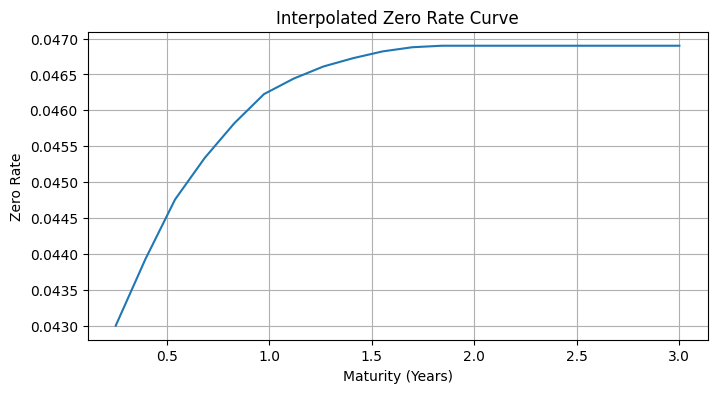

In [21]:
# sanity check on Yield Curve
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [curve.get_zero_rate(T) for T in test_maturities]
dfs = [curve.get_discount_factor(T) for T in test_maturities]
plt.figure(figsize=(8,4))
plt.plot(test_maturities, rates)
plt.title("Interpolated Zero Rate Curve")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate")
plt.grid(True)
plt.show()

# Option Parameters

In [50]:
# Option parameters for all equities
T = 1.0

for name, params in equity_params.items():
    K_i = params["K"]
    call_i = EuropeanCall(S0=params["S0"], K=K_i, T=T,
                          sigma=params["sigma"], yield_curve=curve)
    put_i  = EuropeanPut(S0=params["S0"], K=K_i, T=T,
                         sigma=params["sigma"], yield_curve=curve)
    print(f"{name}: S0=${params['S0']:.2f} | K=${K_i:.2f} | "
          f"T={T} year | sigma={params['sigma']:.2%} | "
          f"Call=${round(call_i.price(), 4)} | Put=${round(put_i.price(), 4)}")

# Keep BHP as default for downstream single-stock cells
S0    = equity_params["BHP"]["S0"]
K     = equity_params["BHP"]["K"]
sigma = equity_params["BHP"]["sigma"]
call  = EuropeanCall(S0=S0, K=K, T=T, sigma=sigma, yield_curve=curve)
put   = EuropeanPut(S0=S0, K=K, T=T, sigma=sigma, yield_curve=curve)

BHP: S0=$57.33 | K=$57.00 | T=1.0 year | sigma=24.92% | Call=$7.1157 | Put=$4.2067
CBA: S0=$165.67 | K=$166.00 | T=1.0 year | sigma=23.17% | Call=$18.8085 | Put=$11.6279
CSL: S0=$99.76 | K=$100.00 | T=1.0 year | sigma=29.54% | Call=$13.7298 | Put=$9.4454
WOW: S0=$34.68 | K=$35.00 | T=1.0 year | sigma=22.30% | Call=$3.6961 | Put=$2.4325


# European Call and European Put Option Prices

In [39]:
# — 2. Create instrument objects for all equities ————
instruments = {}

for name, params in equity_params.items():
    instruments[name] = {
        "equity": EquityPosition(ticker=name, spot=params["S0"]),
        "call":   EuropeanCall(S0=params["S0"], K=params["K"], T=T,
                               sigma=params["sigma"], yield_curve=curve),
        "put":    EuropeanPut(S0=params["S0"], K=params["K"], T=T,
                              sigma=params["sigma"], yield_curve=curve),
        "call_greeks": EuropeanCallGreeks(S0=params["S0"], K=params["K"], T=T,
                                          sigma=params["sigma"], yield_curve=curve),
        "am_put": AmericanPut(S0=params["S0"], K=params["K"], T=T,
                              sigma=params["sigma"], yield_curve=curve, steps=100),
        "asian_call": AsianCall(S0=params["S0"], K=params["K"], T=T,
                                sigma=params["sigma"], yield_curve=curve,
                                simulations=10000),
    }

# Keep BHP shortcuts for downstream cells
equity      = instruments["BHP"]["equity"]
call        = instruments["BHP"]["call"]
put         = instruments["BHP"]["put"]
call_greeks = instruments["BHP"]["call_greeks"]
am_put      = instruments["BHP"]["am_put"]
asian_call  = instruments["BHP"]["asian_call"]

In [40]:
# — 3. Sanity-check instrument pricing and delta ————
for name, inst in instruments.items():
    print(f"\n{name}:")
    print(f"  Equity price: {round(inst['equity'].price(), 4)}")
    print(f"  Equity delta: {round(inst['equity'].delta(), 4)}")
    print(f"  Call price:   {round(inst['call'].price(), 4)}")
    print(f"  Call delta:   {round(inst['call'].delta(), 4)}")
    print(f"  Put price:    {round(inst['put'].price(), 4)}")
    print(f"  Put delta:    {round(inst['put'].delta(), 4)}")


BHP:
  Equity price: 57.33
  Equity delta: 1.0
  Call price:   7.1157
  Call delta:   0.6306
  Put price:    4.2067
  Put delta:    -0.3694

CBA:
  Equity price: 165.67
  Equity delta: 1.0
  Call price:   18.8085
  Call delta:   0.6206
  Put price:    11.6279
  Put delta:    -0.3794

CSL:
  Equity price: 99.76
  Equity delta: 1.0
  Call price:   13.7298
  Call delta:   0.6165
  Put price:    9.4454
  Put delta:    -0.3835

WOW:
  Equity price: 34.68
  Equity delta: 1.0
  Call price:   3.6961
  Call delta:   0.6095
  Put price:    2.4325
  Put delta:    -0.3905


In [41]:
# — 4. Print full Greeks for all equities ————————
for name, inst in instruments.items():
    greeks = inst["call_greeks"].all_greeks()
    print("\n" + "=" * 45)
    print(f"     {name} — EUROPEAN CALL OPTION — GREEKS")
    print("=" * 45)
    print(f"  {'Delta':<10} {greeks['delta']:>10.4f}    (price change per $1 move in S0)")
    print(f"  {'Gamma':<10} {greeks['gamma']:>10.4f}    (rate of change of delta)")
    print(f"  {'Theta':<10} {greeks['theta']:>10.4f}    (price decay per calendar day)")
    print(f"  {'Vega':<10}  {greeks['vega']:>10.4f}    (price change per 1% vol move)")
    print(f"  {'Rho':<10}   {greeks['rho']:>10.4f}    (price change per 1% rate move)")

    print("\n" + "=" * 45)
    print(f"     {name} — AMERICAN PUT OPTION — PRICE")
    print("=" * 45)
    print(f"  {'Binomial Steps':<20} {inst['am_put'].steps:>10}")
    print(f"  {'Price':<20} ${inst['am_put'].price():>9.4f}")
    print(f"  {'Delta':<20} {inst['am_put'].delta():>10.4f}")
    print(f"  {'Gamma':<20} {inst['am_put'].gamma():>10.4f}")
    print(f"  {'Theta':<20} {inst['am_put'].theta():>10.4f}")
    print(f"  {'Vega':<20} {inst['am_put'].vega():>10.4f}")

    print("\n" + "=" * 45)
    print(f"     {name} — ASIAN CALL OPTION — MONTE CARLO")
    print("=" * 45)
    print(f"  {'Simulations':<20} {inst['asian_call'].simulations:>10,}")
    print(f"  {'Price':<20} ${inst['asian_call'].price():>9.4f}")
    print(f"  {'Delta':<20} {inst['asian_call'].delta():>10.4f}")
    print(f"  {'Gamma':<20} {inst['asian_call'].gamma():>10.4f}")
    print(f"  {'Theta':<20} {inst['asian_call'].theta():>10.4f}")
    print(f"  {'Vega':<20} {inst['asian_call'].vega():>10.4f}")
    print("=" * 45)


     BHP — EUROPEAN CALL OPTION — GREEKS
  Delta          0.6306    (price change per $1 move in S0)
  Gamma          0.0264    (rate of change of delta)
  Theta         -0.0111    (price decay per calendar day)
  Vega            0.2163    (price change per 1% vol move)
  Rho              0.2904    (price change per 1% rate move)

     BHP — AMERICAN PUT OPTION — PRICE
  Binomial Steps              100
  Price                $   4.4632
  Delta                   -0.3948
  Gamma                    0.0629
  Theta                   -0.0048
  Vega                     0.2164

     BHP — ASIAN CALL OPTION — MONTE CARLO
  Simulations              10,000
  Price                $   3.9874
  Delta                    0.5890
  Gamma                    0.0494
  Theta                   -0.0060
  Vega                     0.1216

     CBA — EUROPEAN CALL OPTION — GREEKS
  Delta          0.6206    (price change per $1 move in S0)
  Gamma          0.0099    (rate of change of delta)
  Theta         -0.0

In [51]:
# — 5. Create the portfolio object ————————————
portfolio = Portfolio()

# Equal dollar weighting: $100,000 total, 25% to each stock
total_investment = 100000
weight = 0.25

quantities = {
    name: int((total_investment * weight) / equity_params[name]["S0"])
    for name in equity_params
}

print("Portfolio Construction — Equal Dollar Weighting ($100,000 total)")
print("-" * 60)
for name, qty in quantities.items():
    value = qty * equity_params[name]["S0"]
    print(f"  {name}: {qty} shares @ ${equity_params[name]['S0']:.2f} = ${value:,.2f}")
print("-" * 60)
print(f"  Total Equity Value: ${sum(quantities[n] * equity_params[n]['S0'] for n in quantities):,.2f}")

for name, inst in instruments.items():
    portfolio.add_position(inst["equity"], quantity=quantities[name],
                           label=f"Long {name} Equity")
    portfolio.add_position(inst["call"],   quantity=10,
                           label=f"Long {name} Call")
    portfolio.add_position(inst["put"],    quantity=-5,
                           label=f"Short {name} Put")

Portfolio Construction — Equal Dollar Weighting ($100,000 total)
------------------------------------------------------------
  BHP: 436 shares @ $57.33 = $24,995.88
  CBA: 150 shares @ $165.67 = $24,850.50
  CSL: 250 shares @ $99.76 = $24,940.00
  WOW: 720 shares @ $34.68 = $24,969.60
------------------------------------------------------------
  Total Equity Value: $99,755.98


In [52]:
# — 6. Show the portfolio position table ——————————
position_df = portfolio.position_table()
position_df

,Position,Quantity,Unit Value,Position Value,Unit Delta,Position Delta
0,Long BHP Equity,436.0,57.330002,24995.880798,1.000000,436.000000
1,Long BHP Call,10.0,7.115656,71.156564,0.630640,6.306400
2,Short BHP Put,-5.0,4.206718,-21.033588,-0.369360,1.846800
3,Long CBA Equity,150.0,165.669998,24850.499725,1.000000,150.000000
4,Long CBA Call,10.0,18.808485,188.084850,0.620615,6.206150
5,Short CBA Put,-5.0,11.627899,-58.139493,-0.379385,1.896925
6,Long CSL Equity,250.0,99.760002,24940.000534,1.000000,250.000000
7,Long CSL Call,10.0,13.729816,137.298155,0.616500,6.165004
8,Short CSL Put,-5.0,9.445363,-47.226813,-0.383500,1.917498
9,Long WOW Equity,720.0,34.680000,24969.600220,1.000000,720.000000


In [53]:
# — 7. Compute core portfolio outputs ————————————
portfolio_value = portfolio.value()
portfolio_delta = portfolio.delta()

print("Portfolio Value:", round(portfolio_value, 2))
print("Portfolio Delta:", round(portfolio_delta, 4))

Portfolio Value: 100050.92
Portfolio Delta: 1588.3861


In [55]:
# — 8. Compute historical and parametric VaR using combined portfolio returns ——

# Build a weighted return series across all equities
portfolio_returns = sum(
    quantities[name] * equity_params[name]["S0"] * all_data[name]["Close"].pct_change().dropna().reindex(
        all_data["BHP"]["Close"].pct_change().dropna().index, fill_value=0
    )
    for name in instruments
) / portfolio_value

# Historical VaR
hist_var_95 = portfolio.historical_var(portfolio_returns, alpha=0.95, horizon_days=1)
hist_var_90 = portfolio.historical_var(portfolio_returns, alpha=0.90, horizon_days=1)

# Parametric VaR — use portfolio return std as sigma_portfolio
sigma_portfolio = portfolio_returns.std()
param_var_95 = portfolio.parametric_var(sigma_portfolio, alpha=0.95, horizon_days=1)
param_var_90 = portfolio.parametric_var(sigma_portfolio, alpha=0.90, horizon_days=1)

print("=" * 45)
print("  VALUE AT RISK SUMMARY (1-day)")
print("=" * 45)
print(f"  {'Method':<25} {'95% VaR':>8}  {'90% VaR':>8}")
print("-" * 45)
print(f"  {'Historical':<25} ${hist_var_95:>7.2f}  ${hist_var_90:>7.2f}")
print(f"  {'Parametric (Normal)':<25} ${param_var_95:>7.2f}  ${param_var_90:>7.2f}")
print("=" * 45)

  VALUE AT RISK SUMMARY (1-day)
  Method                     95% VaR   90% VaR
---------------------------------------------
  Historical                $1444.58  $ 971.69
  Parametric (Normal)       $1491.55  $1162.11


In [56]:
# — 9. Portfolio risk summary ————————————————
risk_summary = pd.DataFrame({
    "Metric": [
        "Portfolio Value",
        "Portfolio Delta",
        "Historical VaR (95%, 1-day)",
        "Historical VaR (90%, 1-day)",
        "Parametric VaR (95%, 1-day)",
        "Parametric VaR (90%, 1-day)",
    ],
    "Value": [
        portfolio_value,
        portfolio_delta,
        hist_var_95,
        hist_var_90,
        param_var_95,
        param_var_90,
    ]
})
risk_summary

,Metric,Value
0,Portfolio Value,100050.919218
1,Portfolio Delta,1588.386125
2,"Historical VaR (95%, 1-day)",1444.582796
3,"Historical VaR (90%, 1-day)",971.692082
4,"Parametric VaR (95%, 1-day)",1491.549136
5,"Parametric VaR (90%, 1-day)",1162.107740


In [57]:
# — 10. Scenario analysis ————————————————————
def shift_curve(base_curve, rate_shift):
    """Create a new yield curve with a simple parallel shift."""
    shocked_rates = [r + rate_shift for r in base_curve.zero_rates]
    return YieldCurve(
        maturities=base_curve.maturities,
        zero_rates=shocked_rates
    )

def build_scenario_portfolio(base_curve, price_shock=0.0, rate_shift=0.0):
    """Rebuild the full portfolio under shocked inputs."""
    shocked_curve = shift_curve(base_curve, rate_shift)
    shocked_portfolio = Portfolio()

    for name, inst in instruments.items():
        shocked_equity = EquityPosition(
            ticker=name,
            spot=inst["equity"].spot * (1 + price_shock)
        )
        shocked_call = EuropeanCall(
            S0=inst["call"].S0 * (1 + price_shock),
            K=inst["call"].K,
            T=inst["call"].T,
            sigma=inst["call"].sigma,
            yield_curve=shocked_curve
        )
        shocked_put = EuropeanPut(
            S0=inst["put"].S0 * (1 + price_shock),
            K=inst["put"].K,
            T=inst["put"].T,
            sigma=inst["put"].sigma,
            yield_curve=shocked_curve
        )
        shocked_portfolio.add_position(shocked_equity, quantity=quantities[name],
                                       label=f"Long {name} Equity")
        shocked_portfolio.add_position(shocked_call,   quantity=10,
                                       label=f"Long {name} Call")
        shocked_portfolio.add_position(shocked_put,    quantity=-5,
                                       label=f"Short {name} Put")
    return shocked_portfolio

In [58]:
# — 11. Run scenarios ————————————————————————
base_value = portfolio.value()

scenario_inputs = [
    {"Scenario": "Underlying +5%",  "price_shock":  0.05, "rate_shift":  0.0},
    {"Scenario": "Underlying -5%",  "price_shock": -0.05, "rate_shift":  0.0},
    {"Scenario": "Rates +50bps",    "price_shock":  0.0,  "rate_shift":  0.005},
    {"Scenario": "Rates -50bps",    "price_shock":  0.0,  "rate_shift": -0.005},
]

scenario_results = []

for s in scenario_inputs:
    shocked_portfolio = build_scenario_portfolio(
        base_curve=curve,
        price_shock=s["price_shock"],
        rate_shift=s["rate_shift"]
    )
    shocked_value = shocked_portfolio.value()
    pnl           = shocked_value - base_value
    pct_change    = pnl / base_value if base_value != 0 else np.nan

    scenario_results.append({
        "Scenario":      s["Scenario"],
        "Base Value":    base_value,
        "Shocked Value": shocked_value,
        "P&L":           pnl,
        "% Change":      pct_change
    })

scenario_df = pd.DataFrame(scenario_results)
scenario_df

,Scenario,Base Value,Shocked Value,P&L,% Change
0,Underlying +5%,100050.919218,105186.769500,5135.850282,0.051332
1,Underlying -5%,100050.919218,94921.900185,-5129.019034,-0.051264
2,Rates +50bps,100050.919218,100063.922432,13.003214,0.000130
3,Rates -50bps,100050.919218,100037.919441,-12.999777,-0.000130


# Sense Checks

- Volatilty should increase both prices
- Time to maturity should increase both prices as well (calls more than puts)
- S0 should increase call price, decrease put price
- K should increase put price, decrease put price

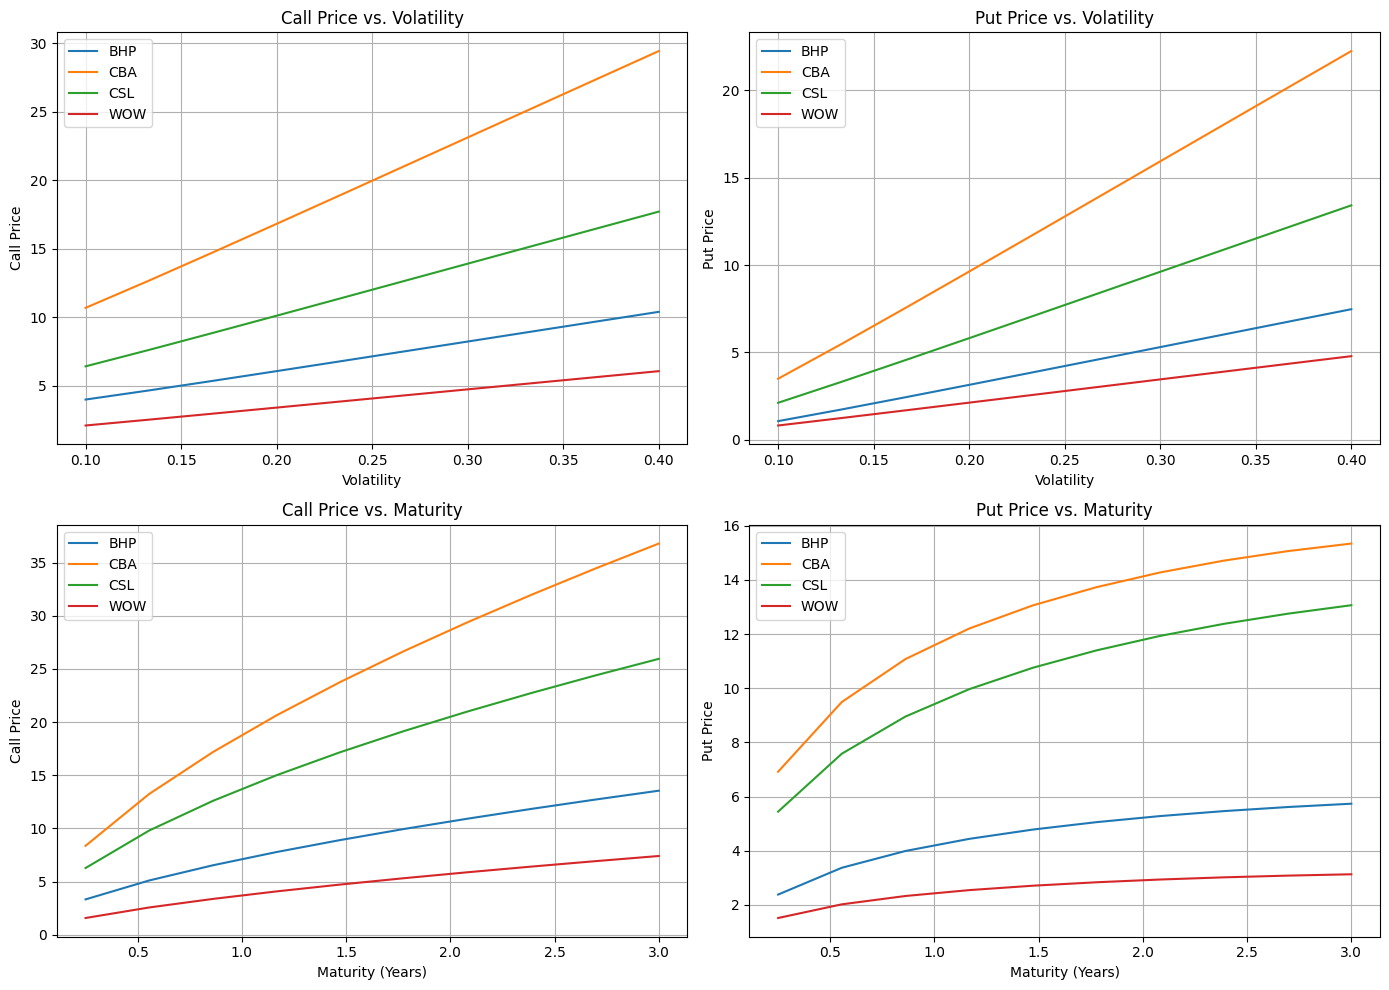

In [59]:
# Sense Checks — run for all equities
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vols = np.linspace(0.1, 0.4, 10)
maturities_range = np.linspace(0.25, 3.0, 10)

for name, params in equity_params.items():
    call_prices_v, put_prices_v = [], []
    for v in vols:
        call_prices_v.append(EuropeanCall(S0=params["S0"], K=params["K"],
                             T=T, sigma=v, yield_curve=curve).price())
        put_prices_v.append(EuropeanPut(S0=params["S0"], K=params["K"],
                            T=T, sigma=v, yield_curve=curve).price())

    call_prices_t, put_prices_t = [], []
    for t in maturities_range:
        call_prices_t.append(EuropeanCall(S0=params["S0"], K=params["K"],
                             T=t, sigma=params["sigma"], yield_curve=curve).price())
        put_prices_t.append(EuropeanPut(S0=params["S0"], K=params["K"],
                            T=t, sigma=params["sigma"], yield_curve=curve).price())

    axes[0, 0].plot(vols, call_prices_v, label=name)
    axes[0, 1].plot(vols, put_prices_v,  label=name)
    axes[1, 0].plot(maturities_range, call_prices_t, label=name)
    axes[1, 1].plot(maturities_range, put_prices_t,  label=name)

axes[0, 0].set_title("Call Price vs. Volatility")
axes[0, 0].set_xlabel("Volatility"); axes[0, 0].set_ylabel("Call Price")
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].set_title("Put Price vs. Volatility")
axes[0, 1].set_xlabel("Volatility"); axes[0, 1].set_ylabel("Put Price")
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].set_title("Call Price vs. Maturity")
axes[1, 0].set_xlabel("Maturity (Years)"); axes[1, 0].set_ylabel("Call Price")
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].set_title("Put Price vs. Maturity")
axes[1, 1].set_xlabel("Maturity (Years)"); axes[1, 1].set_ylabel("Put Price")
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.show()